In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

uploaded = files.upload()

fact_encounter = pd.read_csv("FactEncounter.csv")
fact_cost = pd.read_csv("FactCost.csv")
dim_disease = pd.read_csv("DimDisease.csv")

fact_encounter.columns = fact_encounter.columns.str.strip()
fact_cost.columns = fact_cost.columns.str.strip()
dim_disease.columns = dim_disease.columns.str.strip()

amount_col = [c for c in fact_cost.columns if "amount" in c.lower() or "cost" in c.lower()][0]

cost_master = fact_cost.pivot_table(
    index="Encounter_ID",
    columns="CostType",
    values=amount_col,
    aggfunc="sum",
    fill_value=0
).reset_index()

cost_master["TotalCost"] = cost_master.drop(columns="Encounter_ID").sum(axis=1)

master_hospital = fact_encounter.drop_duplicates("Encounter_ID").merge(
    cost_master,
    on="Encounter_ID",
    how="left"
)

master_hospital = master_hospital.merge(
    dim_disease.drop_duplicates("Disease_ID"),
    on="Disease_ID",
    how="left"
)

master_hospital["CheckinDate"] = pd.to_datetime(master_hospital["CheckinDate"], errors="coerce")
master_hospital["CheckoutDate"] = pd.to_datetime(master_hospital["CheckoutDate"], errors="coerce")

master_hospital["Length_of_Stay"] = (
    master_hospital["CheckoutDate"] - master_hospital["CheckinDate"]
).dt.days

revenue_col = "TotalCost"
disease_col = [c for c in master_hospital.columns if "disease" in c.lower() and "id" not in c.lower()][0]

sns.set_theme(style="whitegrid", palette="Set2")

Saving DimDisease.csv to DimDisease.csv
Saving DimInsurance.csv to DimInsurance.csv
Saving DimRoom.csv to DimRoom.csv
Saving FactCost.csv to FactCost.csv
Saving FactEncounter.csv to FactEncounter.csv


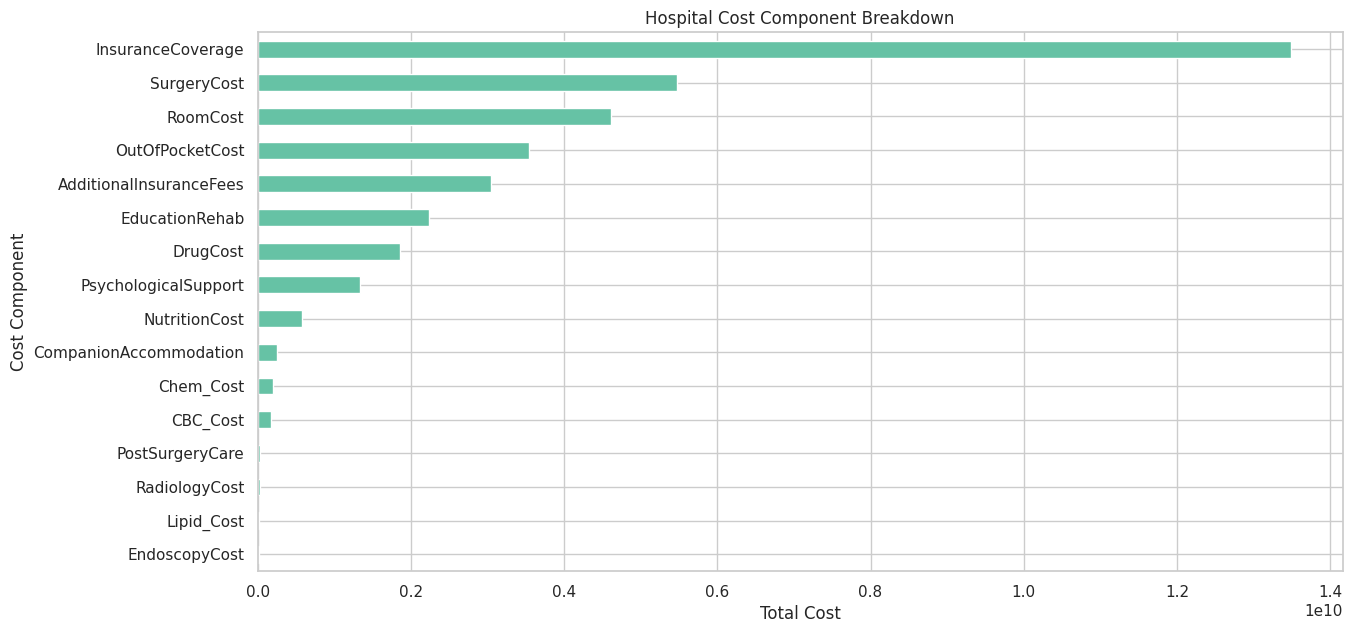

In [ ]:


cost_summary = cost_master.drop(columns=["Encounter_ID", "TotalCost"]).sum().sort_values()

cost_summary.plot(kind="barh", figsize=(14,7))
plt.title("Hospital Cost Component Breakdown")
plt.xlabel("Total Cost")
plt.ylabel("Cost Component")
plt.show()

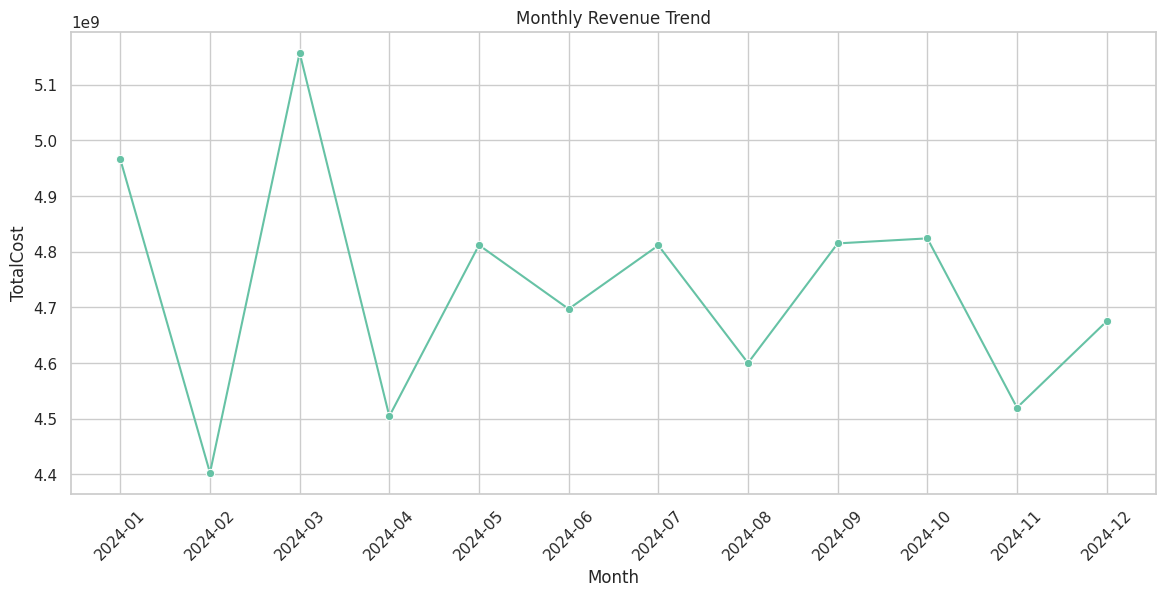

In [ ]:
master_hospital["Month"] = master_hospital["CheckinDate"].dt.to_period("M").astype(str)

monthly = master_hospital.groupby("Month")[revenue_col].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly, x="Month", y=revenue_col, marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

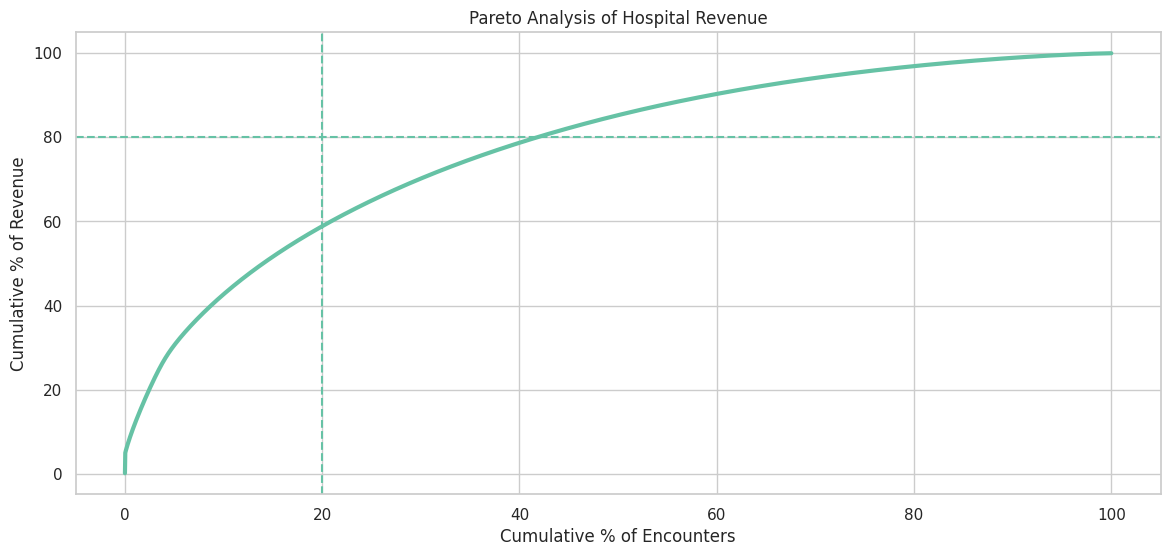

In [ ]:
pareto = master_hospital[[revenue_col]].sort_values(revenue_col, ascending=False).reset_index(drop=True)

pareto["CumulativeRevenue"] = pareto[revenue_col].cumsum()
pareto["RevenuePercent"] = pareto["CumulativeRevenue"] / pareto[revenue_col].sum() * 100
pareto["EncounterPercent"] = (pareto.index + 1) / len(pareto) * 100

plt.figure(figsize=(14,6))
sns.lineplot(data=pareto, x="EncounterPercent", y="RevenuePercent", linewidth=3)
plt.axhline(80, linestyle="--")
plt.axvline(20, linestyle="--")
plt.title("Pareto Analysis of Hospital Revenue")
plt.xlabel("Cumulative % of Encounters")
plt.ylabel("Cumulative % of Revenue")
plt.show()

/tmp/ipykernel_476/1483627532.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment = master_hospital.groupby("RevenueSegment").agg(


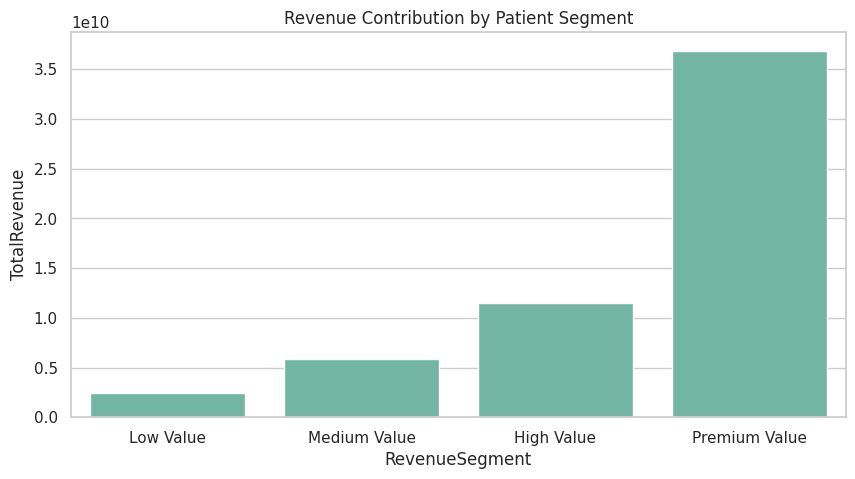

In [ ]:
master_hospital["RevenueSegment"] = pd.qcut(
    master_hospital[revenue_col],
    q=4,
    labels=["Low Value", "Medium Value", "High Value", "Premium Value"]
)

segment = master_hospital.groupby("RevenueSegment").agg(
    TotalRevenue=(revenue_col, "sum"),
    AverageRevenue=(revenue_col, "mean"),
    EncounterCount=("Encounter_ID", "count")
).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=segment, x="RevenueSegment", y="TotalRevenue")
plt.title("Revenue Contribution by Patient Segment")
plt.show()

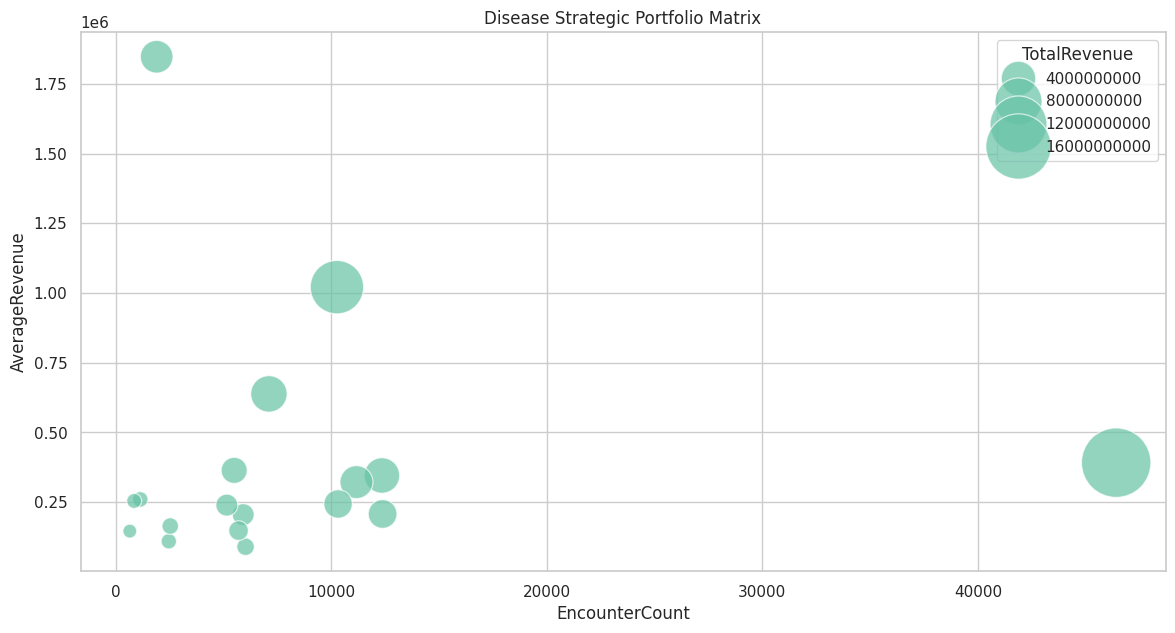

In [ ]:
disease_analysis = master_hospital.groupby(disease_col).agg(
    TotalRevenue=(revenue_col, "sum"),
    AverageRevenue=(revenue_col, "mean"),
    EncounterCount=("Encounter_ID", "count")
).reset_index()

plt.figure(figsize=(14,7))
sns.scatterplot(
    data=disease_analysis,
    x="EncounterCount",
    y="AverageRevenue",
    size="TotalRevenue",
    sizes=(100,2500),
    alpha=0.7
)
plt.title("Disease Strategic Portfolio Matrix")
plt.show()

/tmp/ipykernel_476/733795209.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stay = master_hospital.groupby("StayCategory")[revenue_col].mean().reset_index()


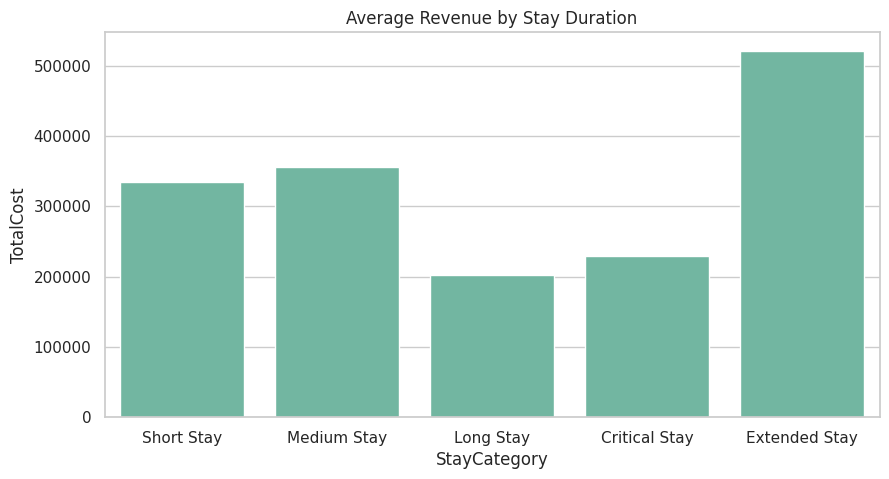

In [ ]:
master_hospital["StayCategory"] = pd.cut(
    master_hospital["Length_of_Stay"],
    bins=[0,3,7,14,30,1000],
    labels=["Short Stay", "Medium Stay", "Long Stay", "Critical Stay", "Extended Stay"]
)

stay = master_hospital.groupby("StayCategory")[revenue_col].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=stay, x="StayCategory", y=revenue_col)
plt.title("Average Revenue by Stay Duration")
plt.show()

/tmp/ipykernel_476/570787608.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ].pivot_table(


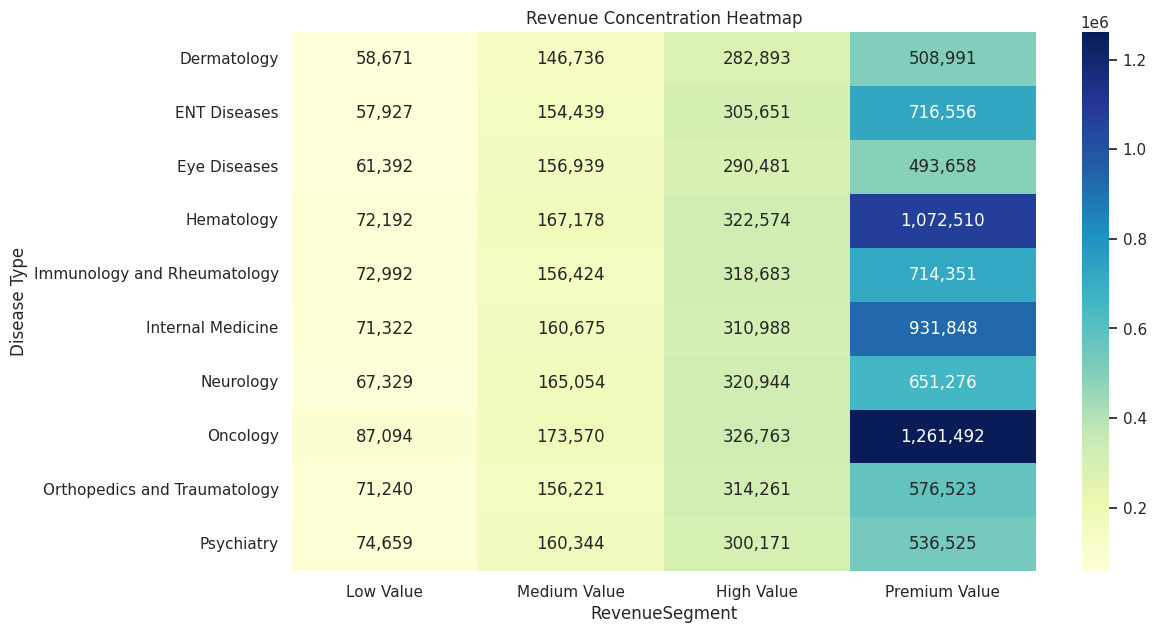

In [ ]:
master_hospital["RevenueSegment"] = pd.qcut(
    master_hospital[revenue_col],
    q=4,
    labels=["Low Value", "Medium Value", "High Value", "Premium Value"]
)

top_diseases = master_hospital[disease_col].value_counts().head(10).index

heatmap_data = master_hospital[
    master_hospital[disease_col].isin(top_diseases)
].pivot_table(
    values=revenue_col,
    index=disease_col,
    columns="RevenueSegment",
    aggfunc="mean"
)

plt.figure(figsize=(12,7))
sns.heatmap(heatmap_data, annot=True, fmt=",.0f", cmap="YlGnBu")
plt.title("Revenue Concentration Heatmap")
plt.show()

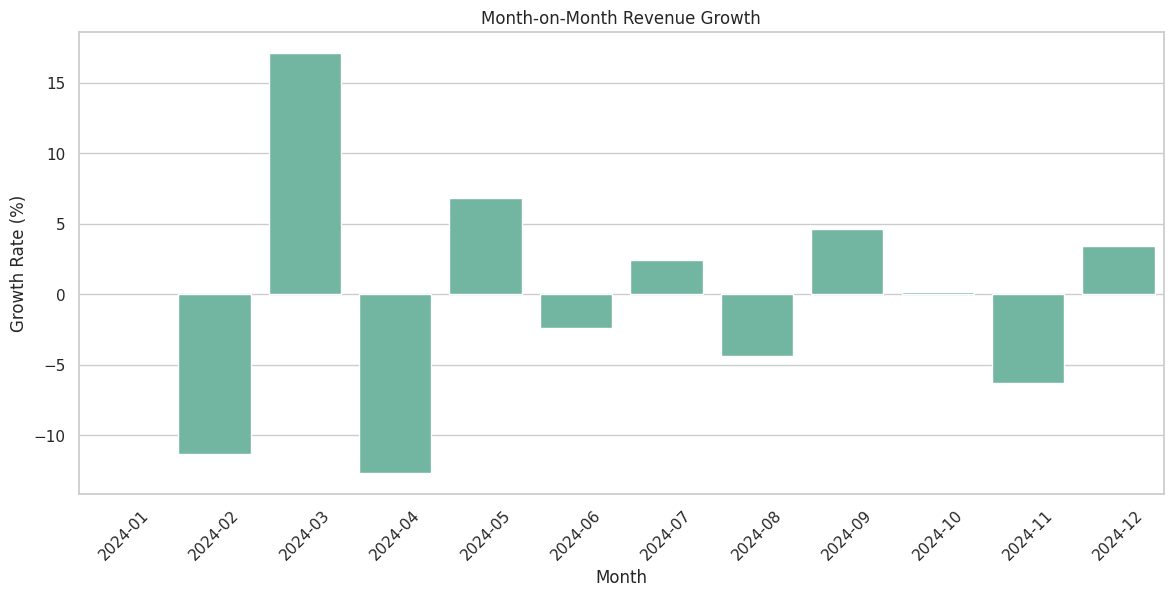

In [ ]:
master_hospital["Month"] = master_hospital["CheckinDate"].dt.to_period("M").astype(str)

monthly = master_hospital.groupby("Month")[revenue_col].sum().reset_index()
monthly["GrowthRate"] = monthly[revenue_col].pct_change() * 100

plt.figure(figsize=(14,6))
sns.barplot(data=monthly, x="Month", y="GrowthRate")
plt.xticks(rotation=45)
plt.title("Month-on-Month Revenue Growth")
plt.ylabel("Growth Rate (%)")
plt.show()

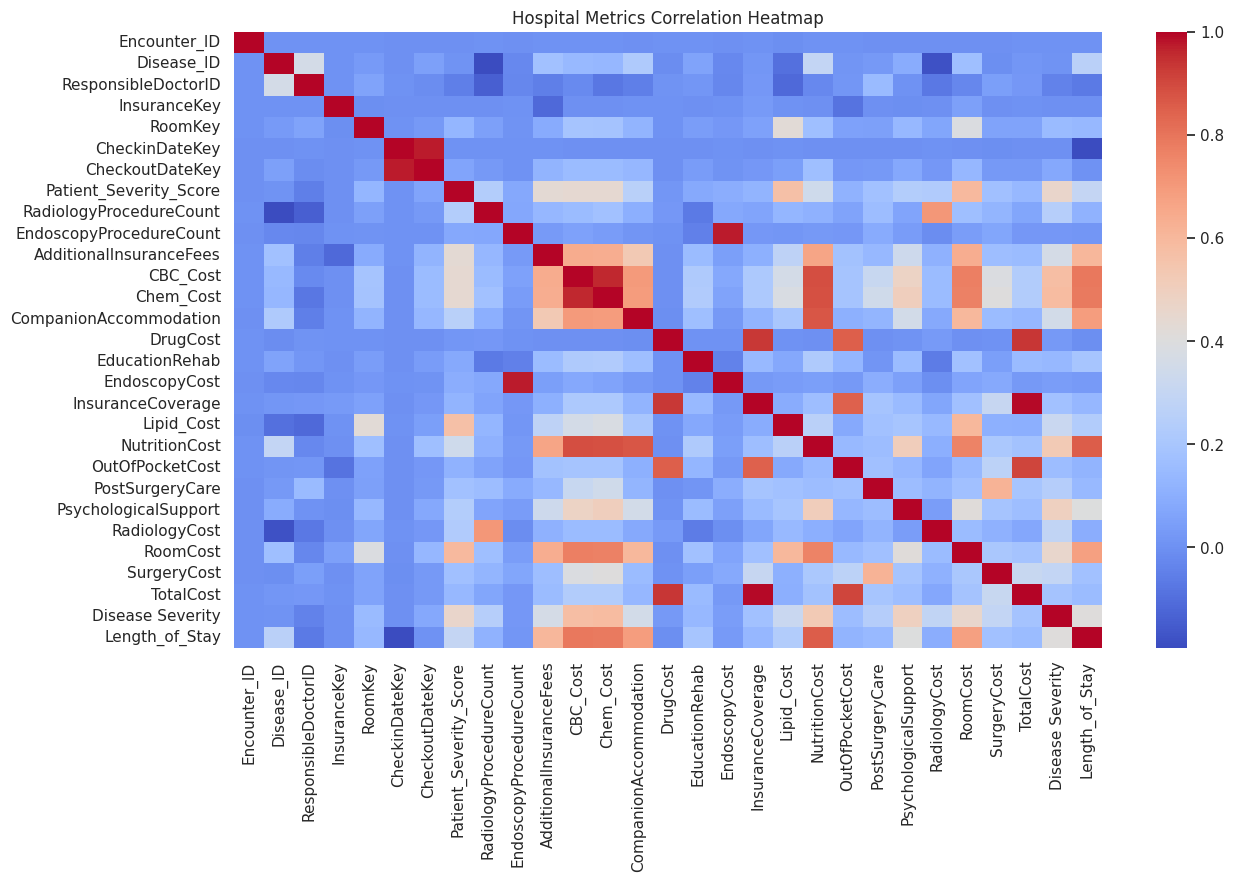

In [ ]:
numeric_cols = master_hospital.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(14,8))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm")
plt.title("Hospital Metrics Correlation Heatmap")
plt.show()